In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load data - UPDATE YourName to your actual windows username
df = pd.read_csv(r"C:\Users\jaisa\OneDrive\Desktop\Projects\Telecom_project\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean data
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print("Data loaded! Shape:", df.shape)
print("Churn counts:", df['Churn'].value_counts().to_dict())

Data loaded! Shape: (7032, 21)
Churn counts: {0: 5163, 1: 1869}


In [9]:
# Prepare X and y
y = df['Churn']
X = df.drop(columns=['Churn', 'customerID'])
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model trained successfully!")
print("Accuracy:", round(accuracy * 100, 2), "%")

Model trained successfully!
Accuracy: 77.68 %


C:\Users\jaisa\AppData\Local\Temp\ipykernel_40304\942254466.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='importance', y='feature', palette='Blues_r')


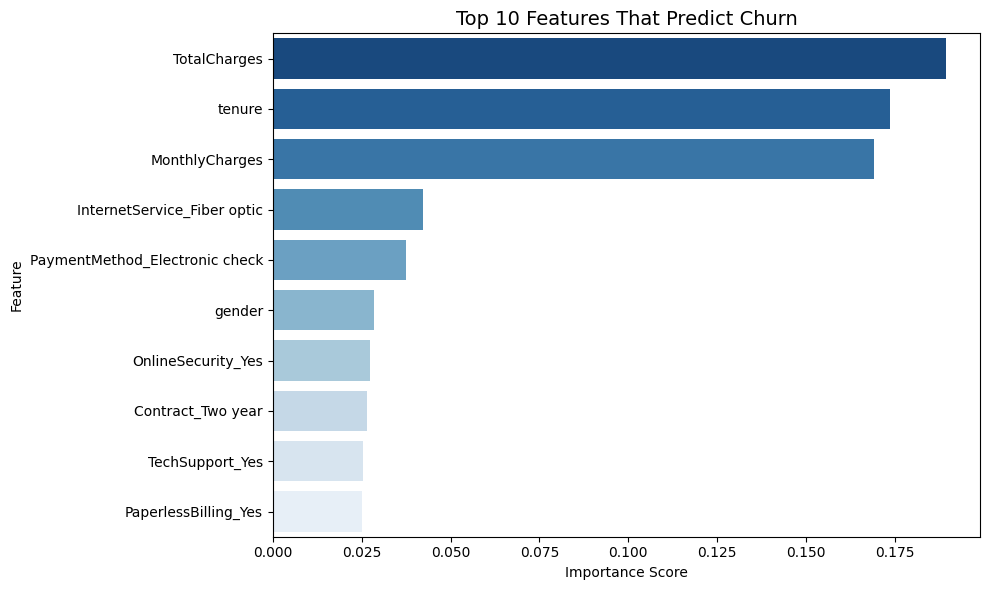

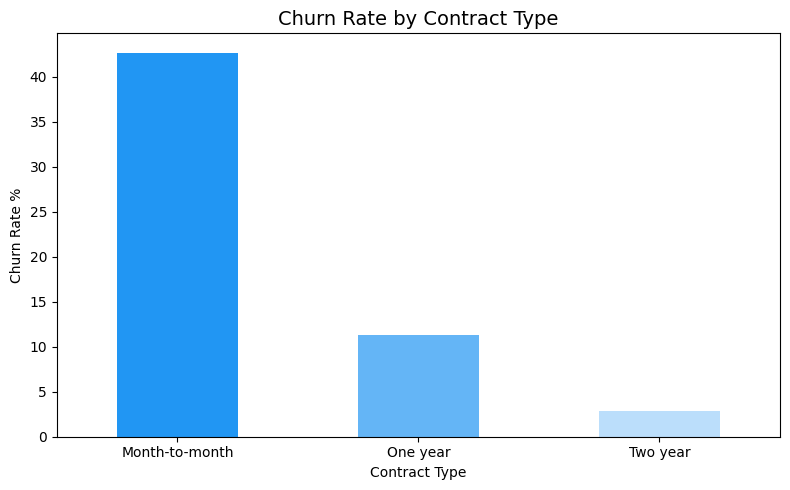

In [10]:
# Chart 1 - Feature Importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})
importance = importance.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='importance', y='feature', palette='Blues_r')
plt.title('Top 10 Features That Predict Churn', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Chart 2 - Churn by Contract Type
contract = df.groupby('Contract')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
contract.plot(kind='bar', color=['#2196F3', '#64B5F6', '#BBDEFB'])
plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\jaisa\AppData\Local\Temp\ipykernel_40304\1852814902.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('tenure_group')['Churn'].mean() * 100


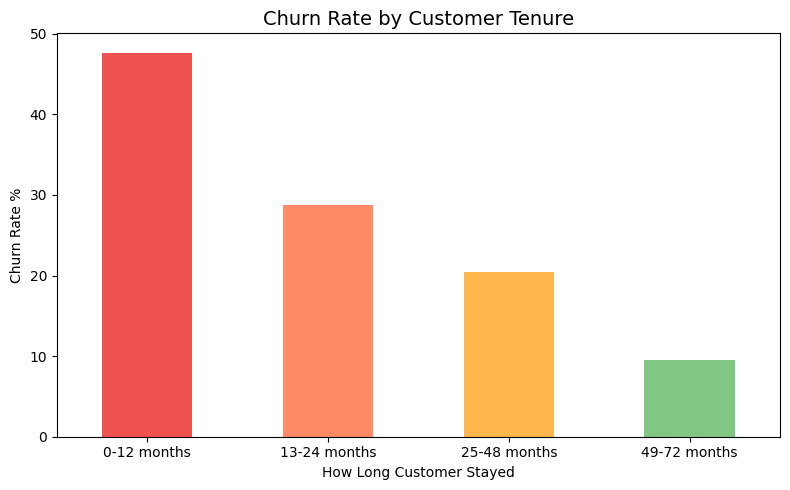

In [11]:
# Create tenure groups
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)

# Calculate churn rate per group
tenure_churn = df.groupby('tenure_group')['Churn'].mean() * 100

# Plot it
plt.figure(figsize=(8, 5))
tenure_churn.plot(
    kind='bar',
    color=['#EF5350', '#FF8A65', '#FFB74D', '#81C784']
)
plt.title('Churn Rate by Customer Tenure', fontsize=14)
plt.xlabel('How Long Customer Stayed')
plt.ylabel('Churn Rate %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()